In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
NUM_ROS      = 256
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("All imports successful.")
print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")

All imports successful.
numpy  2.0.2
pandas 2.2.2


In [ ]:
CSV_PATH = "/content/drive/MyDrive/ML_project/Data/ro_puf_64bit_10000crps (2).csv"

df = pd.read_csv(CSV_PATH)
challenge_cols = [f"c{i}" for i in range(64)]

print(f"Dataset shape    : {df.shape}")
print(f"Challenge cols   : c0 ... c63  ({len(challenge_cols)} bits)")
print(f"Extra cols       : ro_i, ro_j, response")
print(f"Total CRPs       : {len(df)}")
print()
print("First 3 rows:")
df.head(3)

Dataset shape    : (10000, 67)
Challenge cols   : c0 ... c63  (64 bits)
Extra cols       : ro_i, ro_j, response
Total CRPs       : 10000

First 3 rows:


,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c57,c58,c59,c60,c61,c62,c63,ro_i,ro_j,response
0,1,0,0,0,0,1,0,0,0,1,...,0,0,0,1,0,0,1,185,137,0
1,1,1,0,1,1,1,0,0,1,1,...,0,0,0,1,1,0,0,108,140,1
2,0,0,1,1,0,0,0,0,1,0,...,0,0,0,1,0,1,0,231,10,1


Response distribution:
response
0    5037
1    4963
Name: count, dtype: int64

Balance ratio 0/1 : 1.0149
Fraction of 1s    : 0.4963


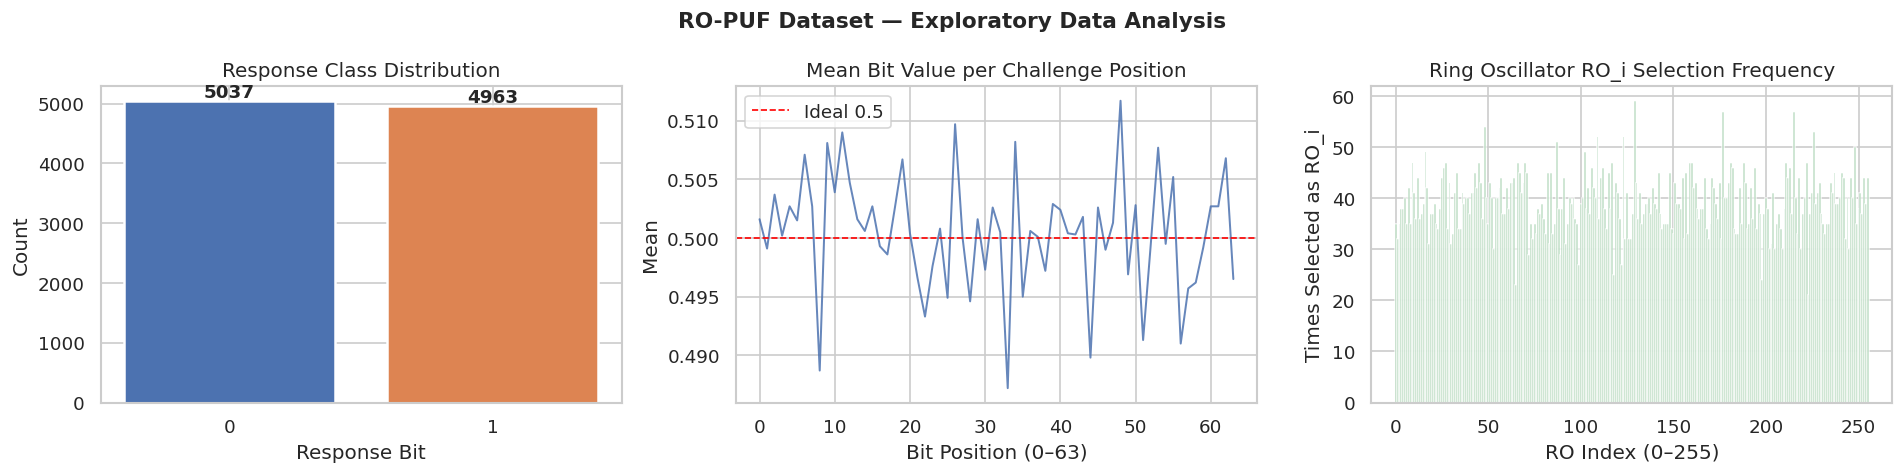


Unique RO pairs observed : 9267
Total possible pairs     : 65280
Coverage                 : 14.2%

>> With only 10K CRPs across 65,280 possible pairs, most pairs
   appear 0 or 1 times — this is WHY raw bit models fail.


In [ ]:
response_counts = df["response"].value_counts().sort_index()
print("Response distribution:")
print(response_counts)
print(f"\nBalance ratio 0/1 : {response_counts[0] / response_counts[1]:.4f}")
print(f"Fraction of 1s    : {response_counts[1] / len(df):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (A) Class balance
axes[0].bar(["0", "1"], response_counts.values,
            color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Response Class Distribution")
axes[0].set_xlabel("Response Bit")
axes[0].set_ylabel("Count")
for i, v in enumerate(response_counts.values):
    axes[0].text(i, v + 60, str(v), ha="center", fontweight="bold")

# (B) Mean bit value per challenge position
bit_means = df[challenge_cols].mean()
axes[1].plot(bit_means.values, linewidth=1.2, color="#4C72B0", alpha=0.85)
axes[1].axhline(0.5, color="red", linestyle="--", linewidth=1, label="Ideal 0.5")
axes[1].set_title("Mean Bit Value per Challenge Position")
axes[1].set_xlabel("Bit Position (0–63)")
axes[1].set_ylabel("Mean")
axes[1].legend()

# (C) RO pair selection frequency — how often each RO appears as ro_i
ro_i_counts = df["ro_i"].value_counts().sort_index()
axes[2].bar(ro_i_counts.index, ro_i_counts.values,
            color="#55A868", width=1.0, alpha=0.75)
axes[2].set_title("Ring Oscillator RO_i Selection Frequency")
axes[2].set_xlabel("RO Index (0–255)")
axes[2].set_ylabel("Times Selected as RO_i")

plt.suptitle("RO-PUF Dataset — Exploratory Data Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Coverage analysis — how many unique RO pairs have been observed?
pairs = set(zip(df["ro_i"], df["ro_j"]))
total_possible = NUM_ROS * (NUM_ROS - 1)
print(f"\nUnique RO pairs observed : {len(pairs)}")
print(f"Total possible pairs     : {total_possible}")
print(f"Coverage                 : {len(pairs)/total_possible*100:.1f}%")
print()
print(">> With only 10K CRPs across 65,280 possible pairs, most pairs")
print("   appear 0 or 1 times — this is WHY raw bit models fail.")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  THREE feature representations, explained:
#
#  1. Raw bits  (64-d) : the literal challenge — useless for RO-PUF
#                        because bits are just a hash key to find
#                        two oscillators. No signal for the model.
#
#  2. Parity    (64-d) : suffix XOR products — correct for Arbiter
#                        PUFs (delay chains), wrong for RO-PUFs.
#
#  3. RO one-hot (512-d): explicitly tells the model WHICH two
#                         oscillators compete. LR/SVM/MLP can now
#                         learn freq[i] > freq[j] for each pair.
#                         This is the causally correct feature.
# ════════════════════════════════════════════════════════════════

def parity_features(X_bits):
    """Suffix XOR product transform — standard for Arbiter PUFs."""
    X_pm = 2 * X_bits.astype(np.float32) - 1   # {0,1} -> {-1,+1}
    return np.fliplr(np.cumprod(np.fliplr(X_pm), axis=1))


def challenge_to_ro_indices(X_bits, num_ros=256):
    """
    Decode ro_i and ro_j from challenge bits.
    Replicates OscillatorPUF.py logic exactly:
      - left  32 bits -> bits_to_int() % num_ros -> ro_i
      - right 32 bits -> bits_to_int() % num_ros -> ro_j
      - if ro_i == ro_j: ro_j = (ro_j + 1) % num_ros
    """
    powers = 2 ** np.arange(31, -1, -1, dtype=np.int64)
    ro_i   = (X_bits[:, :32].astype(np.int64) @ powers) % num_ros
    ro_j   = (X_bits[:, 32:].astype(np.int64) @ powers) % num_ros
    mask   = ro_i == ro_j
    ro_j[mask] = (ro_j[mask] + 1) % num_ros
    return ro_i, ro_j


def build_ro_onehot(X_bits, num_ros=256):
    """
    One-hot encode ro_i and ro_j, concatenate into a 512-d vector.

    Example for num_ros=4, ro_i=1, ro_j=3:
      feat_i = [0, 1, 0, 0]
      feat_j = [0, 0, 0, 1]
      output = [0, 1, 0, 0,  0, 0, 0, 1]  (length 8)

    LR weight on feat_i[k] learns the contribution of RO k
    being the 'left' oscillator. Same for feat_j[k].
    The model effectively learns a score per oscillator and
    predicts which side wins.
    """
    N      = len(X_bits)
    ro_i, ro_j = challenge_to_ro_indices(X_bits, num_ros)

    feat_i = np.zeros((N, num_ros), dtype=np.float32)
    feat_j = np.zeros((N, num_ros), dtype=np.float32)
    feat_i[np.arange(N), ro_i] = 1.0
    feat_j[np.arange(N), ro_j] = 1.0

    return np.hstack([feat_i, feat_j])   # shape (N, 512)



X_raw    = df[challenge_cols].values.astype(np.float32)   # (10000, 64)
X_parity = parity_features(X_raw)                          # (10000, 64)
X_ro     = build_ro_onehot(X_raw, NUM_ROS)                 # (10000, 512)
y        = df["response"].values

ro_i_dec, ro_j_dec = challenge_to_ro_indices(X_raw)
assert np.all(ro_i_dec == df["ro_i"].values), "ro_i mismatch!"
assert np.all(ro_j_dec == df["ro_j"].values), "ro_j mismatch!"
print("✓ RO index decoding verified against CSV ground truth\n")

print(f"X_raw    shape : {X_raw.shape}    — raw 64 bits")
print(f"X_parity shape : {X_parity.shape}    — parity transform")
print(f"X_ro     shape : {X_ro.shape}  — RO one-hot (correct feature)")

X_raw_tr, X_raw_te, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

X_par_tr, X_par_te, _, _ = train_test_split(
    X_parity, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

X_ro_tr, X_ro_te, _, _ = train_test_split(
    X_ro, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"\nTrain samples : {X_raw_tr.shape[0]}")
print(f"Test  samples : {X_raw_te.shape[0]}")

✓ RO index decoding verified against CSV ground truth

X_raw    shape : (10000, 64)    — raw 64 bits
X_parity shape : (10000, 64)    — parity transform
X_ro     shape : (10000, 512)  — RO one-hot (correct feature)

Train samples : 8000
Test  samples : 2000


In [ ]:
results = {}

configs_lr = [
    ("LR (raw)",    X_raw_tr, X_raw_te),
    ("LR (parity)", X_par_tr, X_par_te),
    ("LR (RO)",     X_ro_tr,  X_ro_te),
]

for name, X_tr_, X_te_ in configs_lr:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(C=1.0, max_iter=2000,
                                      solver="lbfgs",
                                      random_state=RANDOM_STATE))
    ])
    pipe.fit(X_tr_, y_tr)
    y_pred = pipe.predict(X_te_)
    acc    = accuracy_score(y_te, y_pred)
    results[name] = {"acc": acc, "y_pred": y_pred,
                     "model": pipe, "X_te": X_te_}

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(classification_report(y_te, y_pred,
                                 target_names=["Resp=0","Resp=1"],
                                 digits=4))

X_raw shape    : (10000, 64)
X_parity shape : (10000, 64)
y shape        : (10000,)
X_raw shape      : (10000, 64)
X_parity shape   : (10000, 64)
X_ro shape       : (10000, 512)   <-- RO one-hot
X_combined shape : (10000, 640)  <-- all features

Train samples : 8000
Test  samples : 2000
y_train 1-fraction : 0.4963
y_test  1-fraction : 0.4965


In [ ]:

results = {}

configs_lr = [
    ("LR (raw)",    X_raw_tr, X_raw_te),
    ("LR (parity)", X_par_tr, X_par_te),
    ("LR (RO)",     X_ro_tr,  X_ro_te),
]

for name, X_tr_, X_te_ in configs_lr:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(C=1.0, max_iter=2000,
                                      solver="lbfgs",
                                      random_state=RANDOM_STATE))
    ])
    pipe.fit(X_tr_, y_tr)
    y_pred = pipe.predict(X_te_)
    acc    = accuracy_score(y_te, y_pred)

    results[name] = {
        "acc":    acc,
        "y_pred": y_pred,
        "model":  pipe,
        "X_te":   X_te_
    }

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(classification_report(y_te, y_pred,
                                 target_names=["Resp=0","Resp=1"],
                                 digits=4))

print("Results dict keys so far:", list(results.keys()))

  LR (raw)
  Test Accuracy : 0.5290
              precision    recall  f1-score   support

      Resp=0     0.5311    0.5511    0.5409      1007
      Resp=1     0.5267    0.5065    0.5164       993

    accuracy                         0.5290      2000
   macro avg     0.5289    0.5288    0.5287      2000
weighted avg     0.5289    0.5290    0.5288      2000

  LR (parity)
  Test Accuracy : 0.5325
              precision    recall  f1-score   support

      Resp=0     0.5350    0.5462    0.5405      1007
      Resp=1     0.5298    0.5186    0.5242       993

    accuracy                         0.5325      2000
   macro avg     0.5324    0.5324    0.5324      2000
weighted avg     0.5324    0.5325    0.5324      2000

  LR (RO)
  Test Accuracy : 0.9810
              precision    recall  f1-score   support

      Resp=0     0.9773    0.9851    0.9812      1007
      Resp=1     0.9848    0.9768    0.9808       993

    accuracy                         0.9810      2000
   macro avg     0

In [ ]:
configs_svm = [
    ("SVM (raw)",    X_raw_tr, X_raw_te),
    ("SVM (parity)", X_par_tr, X_par_te),
    ("SVM (RO)",     X_ro_tr,  X_ro_te),
]

for name, X_tr_, X_te_ in configs_svm:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", C=10.0, gamma="scale",
                       probability=True,
                       random_state=RANDOM_STATE))
    ])
    pipe.fit(X_tr_, y_tr)
    y_pred = pipe.predict(X_te_)
    acc    = accuracy_score(y_te, y_pred)

    results[name] = {
        "acc":    acc,
        "y_pred": y_pred,
        "model":  pipe,
        "X_te":   X_te_
    }

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(classification_report(y_te, y_pred,
                                 target_names=["Resp=0","Resp=1"],
                                 digits=4))

print("Results dict keys so far:", list(results.keys()))

  SVM (raw)
  Test Accuracy : 0.5620
              precision    recall  f1-score   support

      Resp=0     0.5647    0.5680    0.5663      1007
      Resp=1     0.5593    0.5559    0.5576       993

    accuracy                         0.5620      2000
   macro avg     0.5620    0.5620    0.5620      2000
weighted avg     0.5620    0.5620    0.5620      2000

  SVM (parity)
  Test Accuracy : 0.5680
              precision    recall  f1-score   support

      Resp=0     0.5699    0.5789    0.5744      1007
      Resp=1     0.5660    0.5569    0.5614       993

    accuracy                         0.5680      2000
   macro avg     0.5680    0.5679    0.5679      2000
weighted avg     0.5680    0.5680    0.5679      2000

  SVM (RO)
  Test Accuracy : 0.9710
              precision    recall  f1-score   support

      Resp=0     0.9712    0.9712    0.9712      1007
      Resp=1     0.9708    0.9708    0.9708       993

    accuracy                         0.9710      2000
   macro avg   

In [ ]:
configs_mlp = [
    ("MLP (raw)",    X_raw_tr, X_raw_te),
    ("MLP (parity)", X_par_tr, X_par_te),
    ("MLP (RO)",     X_ro_tr,  X_ro_te),
]

for name, X_tr_, X_te_ in configs_mlp:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=RANDOM_STATE,
            verbose=False
        ))
    ])
    pipe.fit(X_tr_, y_tr)
    y_pred = pipe.predict(X_te_)
    acc    = accuracy_score(y_te, y_pred)

    results[name] = {
        "acc":    acc,
        "y_pred": y_pred,
        "model":  pipe,
        "X_te":   X_te_
    }

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Epochs run    : {pipe.named_steps['clf'].n_iter_}")
    print(classification_report(y_te, y_pred,
                                 target_names=["Resp=0","Resp=1"],
                                 digits=4))

print("Results dict keys so far:", list(results.keys()))

  MLP (raw)
  Test Accuracy : 0.5380
  Epochs run    : 31
              precision    recall  f1-score   support

      Resp=0     0.5380    0.5839    0.5600      1007
      Resp=1     0.5380    0.4914    0.5137       993

    accuracy                         0.5380      2000
   macro avg     0.5380    0.5377    0.5368      2000
weighted avg     0.5380    0.5380    0.5370      2000

  MLP (parity)
  Test Accuracy : 0.5190
  Epochs run    : 25
              precision    recall  f1-score   support

      Resp=0     0.5185    0.6266    0.5674      1007
      Resp=1     0.5198    0.4099    0.4583       993

    accuracy                         0.5190      2000
   macro avg     0.5191    0.5182    0.5129      2000
weighted avg     0.5191    0.5190    0.5133      2000

  MLP (RO)
  Test Accuracy : 0.9575
  Epochs run    : 32
              precision    recall  f1-score   support

      Resp=0     0.9511    0.9652    0.9581      1007
      Resp=1     0.9642    0.9496    0.9569       993

    ac

In [ ]:

print("Models currently in results dict:")
for k in results:
    print(f"  {k}")

rows = []
for name, res in results.items():
    proba = res["model"].predict_proba(res["X_te"])[:, 1]
    auc   = roc_auc_score(y_te, proba)
    feat  = ("RO one-hot"  if "(RO)"     in name
             else "Parity" if "(parity)" in name
             else "Raw bits")
    rows.append({
        "Model":         name,
        "Feature Set":   feat,
        "Test Accuracy": round(res["acc"], 4),
        "ROC-AUC":       round(auc, 4),
    })

summary_df = (pd.DataFrame(rows)
                .sort_values("Test Accuracy", ascending=False)
                .reset_index(drop=True))

print()
print("=" * 62)
print("   Model Comparison Summary")
print("=" * 62)
print(summary_df.to_string(index=False))
summary_df

Models currently in results dict:
  LR (raw)
  LR (parity)
  LR (RO)
  SVM (raw)
  SVM (parity)
  SVM (RO)
  MLP (raw)
  MLP (parity)
  MLP (RO)

   Model Comparison Summary
       Model Feature Set  Test Accuracy  ROC-AUC
     LR (RO)  RO one-hot         0.9810   0.9984
    SVM (RO)  RO one-hot         0.9710   0.9969
    MLP (RO)  RO one-hot         0.9575   0.9932
SVM (parity)      Parity         0.5680   0.5961
   SVM (raw)    Raw bits         0.5620   0.5802
   MLP (raw)    Raw bits         0.5380   0.5539
 LR (parity)      Parity         0.5325   0.5452
    LR (raw)    Raw bits         0.5290   0.5508
MLP (parity)      Parity         0.5190   0.5284


,Model,Feature Set,Test Accuracy,ROC-AUC
0,LR (RO),RO one-hot,0.9810,0.9984
1,SVM (RO),RO one-hot,0.9710,0.9969
2,MLP (RO),RO one-hot,0.9575,0.9932
3,SVM (parity),Parity,0.5680,0.5961
4,SVM (raw),Raw bits,0.5620,0.5802
5,MLP (raw),Raw bits,0.5380,0.5539
6,LR (parity),Parity,0.5325,0.5452
7,LR (raw),Raw bits,0.5290,0.5508
8,MLP (parity),Parity,0.5190,0.5284
